훈련 데이터: (50000, 32, 32, 3)
테스트 데이터: (10000, 32, 32, 3)
훈련: (40000, 32, 32, 3), 검증: (10000, 32, 32, 3)
훈련 라벨 분포: [4000 4000 4000 4000 4000 4000 4000 4000 4000 4000]


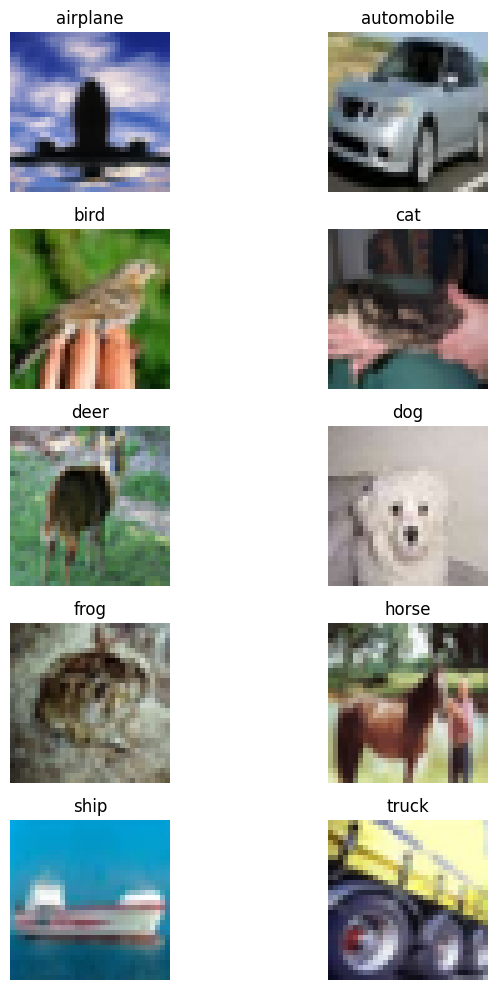

이미지 최소값: 0.000, 최대값: 1.000
평균: 0.473, 표준편차: 0.252


In [2]:
import numpy as np

import pandas as pd

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

import tensorflow as tf

from tensorflow import keras

from tensorflow.keras import layers, datasets

import warnings

warnings.filterwarnings('ignore')

# 1. Keras에서 CIFAR-10 데이터 직접 로드

(X_train_full, y_train_full), (X_test, y_test) = datasets.cifar10.load_data()

X_train_full = X_train_full.astype('float32')

X_test = X_test.astype('float32')

y_train_full = y_train_full.flatten()

y_test = y_test.flatten()

print(f"훈련 데이터: {X_train_full.shape}")  # (50000, 32, 32, 3)

print(f"테스트 데이터: {X_test.shape}")      # (10000, 32, 32, 3)

# 2. 정규화 (0~255 → 0~1)

X_train_full = X_train_full / 255.0

X_test = X_test / 255.0

# 3. 훈련/검증 분할 (8:2)

# ✅ TODO: train_test_split 사용하여 분할

X_train, X_val, y_train, y_val = train_test_split(

    X_train_full, y_train_full,

    test_size=0.2,

    random_state=42,

    stratify=y_train_full  # 클래스 비율 유지

)

print(f"훈련: {X_train.shape}, 검증: {X_val.shape}")

print(f"훈련 라벨 분포: {np.bincount(y_train)}")

# 4. 클래스 이름 정의

class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',

               'dog', 'frog', 'horse', 'ship', 'truck']

# 5. 시각화: 각 클래스별 샘플 이미지

fig, axes = plt.subplots(5, 2, figsize=(8, 10))

for class_idx in range(10):

    # ✅ TODO: 각 클래스의 이미지 인덱스 찾기

    indices = np.where(y_train == class_idx)[0]

    idx = indices[0] if len(indices) > 0 else 0

    

    row, col = class_idx // 2, class_idx % 2

    axes[row, col].imshow(X_train[idx])

    axes[row, col].set_title(class_names[class_idx])

    axes[row, col].axis('off')  # 힌트: axis

plt.tight_layout()

plt.show()

# 6. 이미지 샘플 확인 (데이터 형태, 픽셀값 범위)

print(f"이미지 최소값: {X_train.min():.3f}, 최대값: {X_train.max():.3f}")

print(f"평균: {X_train.mean():.3f}, 표준편차: {X_train.std():.3f}")


In [5]:
model = keras.Sequential([

    # 합성곱층 1: 32개 필터, 3×3 크기

    layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)),

    # ✅ TODO: 풀링층 추가

    # 2×2 Max Pooling으로 크기 절반으로 축소

    layers.MaxPooling2D(pool_size=(2, 2)),

    

    # 합성곱층 2: 64개 필터

    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),

    # ✅ TODO: 풀링층 추가

    layers.MaxPooling2D(pool_size=(2, 2)),

    

    # 합성곱층 3: 128개 필터

    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),

    # ✅ TODO: 풀링층 추가

    layers.MaxPooling2D(pool_size=(2, 2)),

    

    # Flatten: 2D 특징맵을 1D 벡터로 변환

    layers.Flatten(),

    

    # Dense층: 분류

    layers.Dense(256, activation='relu'),

    # ✅ TODO: Dropout 추가 (과적합 방지)

    # Dropout(0.5) = 50% 뉴런 무작위 비활성화

    layers.Dropout(0.5),

    

    # 출력층: 10개 클래스

    # ✅ TODO: 활성화함수 선택 (다중분류)

    layers.Dense(10, activation='softmax')

])

# 2. 모델 컴파일

model.compile(

    optimizer=keras.optimizers.Adam(learning_rate=0.001),

    # ✅ TODO: 손실함수 선택

    # 옵션: 'categorical_crossentropy', 'sparse_categorical_crossentropy'

    loss='sparse_categorical_crossentropy',

    metrics=['accuracy']

)

# 3. 모델 요약

model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 620,362 (2.37 MB)

 Trainable params: 620,362 (2.37 MB)

 Non-trainable params: 0 (0.00 B)

In [6]:
early_stop = keras.callbacks.EarlyStopping(

    monitor='val_loss',

    patience=10,

    restore_best_weights=True

)

# 훈련

history = model.fit(

    X_train, y_train,

    validation_data=(X_val, y_val),

    epochs=100,

    batch_size=128,  # CIFAR-10은 작은 이미지라 배치 크기 증가 가능

    # ✅ TODO: 콜백 전달

    callbacks=[early_stop],

    verbose=1

)

print(f"훈련 완료! 총 {len(history.history['loss'])}개 에포크")

pd.DataFrame(history.history).tail(10)


Epoch 1/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 49s 149ms/step - accuracy: 0.2766 - loss: 1.9390 - val_accuracy: 0.4788 - val_loss: 1.4247
Epoch 2/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 44s 139ms/step - accuracy: 0.5092 - loss: 1.3626 - val_accuracy: 0.5856 - val_loss: 1.1654
Epoch 3/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 43s 138ms/step - accuracy: 0.5882 - loss: 1.1605 - val_accuracy: 0.6516 - val_loss: 0.9919
Epoch 4/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 43s 138ms/step - accuracy: 0.6412 - loss: 1.0220 - val_accuracy: 0.6824 - val_loss: 0.9089
Epoch 5/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 82s 138ms/step - accuracy: 0.6764 - loss: 0.9253 - val_accuracy: 0.6937 - val_loss: 0.8769
Epoch 6/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 43s 138ms/step - accuracy: 0.7084 - loss: 0.8375 - val_accuracy: 0.7133 - val_loss: 0.8187
Epoch 7/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 43s 139ms/step - accuracy: 0.7330 - loss: 0.7652 - val_accuracy: 0.7137 - val_loss: 0.8134
Epoch 8/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 44s 141ms/step - accuracy: 0.7510 -

,accuracy,loss,val_accuracy,val_loss
12,0.826900,0.490754,0.7403,0.818206
13,0.836825,0.451643,0.7433,0.820787
14,0.848400,0.425069,0.7444,0.832386
15,0.859175,0.391895,0.7425,0.827131
16,0.870425,0.361834,0.7477,0.839236
17,0.878875,0.337249,0.7445,0.893113
18,0.884425,0.320669,0.7417,0.907041
19,0.893450,0.290476,0.7494,0.907892
20,0.899675,0.274232,0.7415,1.001811
21,0.906450,0.254789,0.7497,0.979650


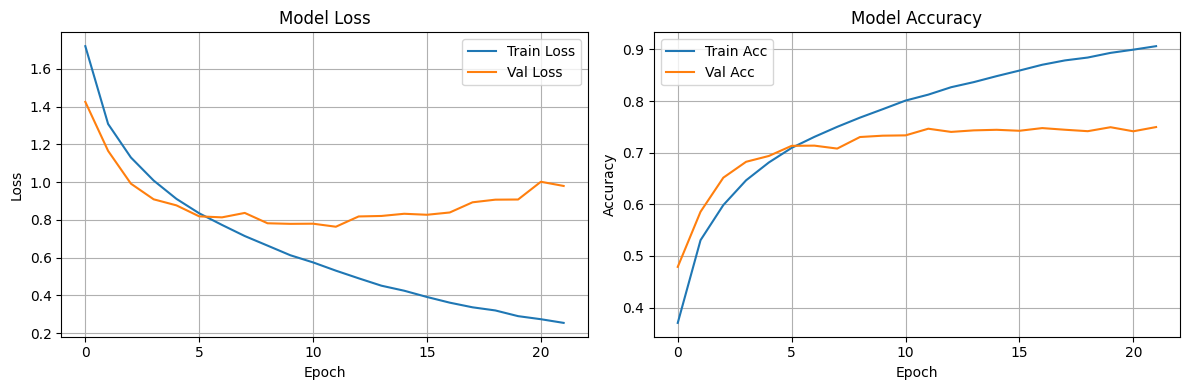

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.7486 - loss: 0.7578

=== 검증 성능 ===
Loss: 0.7638
정확도: 0.7465 (74.65%)
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.7457 - loss: 0.7702

=== 테스트 성능 (최종) ===
Loss: 0.7704
정확도: 0.7432 (74.32%)
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step

예측 신뢰도:
  평균: 0.7985
  최소: 0.1685
  최대: 1.0000


In [10]:
# 1. 훈련/검증 손실 & 정확도 시각화

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 손실

axes[0].plot(history.history['loss'], label='Train Loss')

axes[0].plot(history.history['val_loss'], label='Val Loss')

axes[0].set_xlabel('Epoch')

axes[0].set_ylabel('Loss')

axes[0].set_title('Model Loss')

axes[0].legend()

axes[0].grid(True)

# 정확도

axes[1].plot(history.history['accuracy'], label='Train Acc')

axes[1].plot(history.history['val_accuracy'], label='Val Acc')

axes[1].set_xlabel('Epoch')

axes[1].set_ylabel('Accuracy')

axes[1].set_title('Model Accuracy')

axes[1].legend()

axes[1].grid(True)

plt.tight_layout()

plt.show()

# 2. 최종 성능 평가

val_loss, val_acc = model.evaluate(X_val, y_val)

print(f"\n=== 검증 성능 ===")

print(f"Loss: {val_loss:.4f}")

print(f"정확도: {val_acc:.4f} ({val_acc*100:.2f}%)")

# 테스트 성능 (최종 평가)

test_loss, test_acc = model.evaluate(X_test, y_test)

print(f"\n=== 테스트 성능 (최종) ===")

print(f"Loss: {test_loss:.4f}")

print(f"정확도: {test_acc:.4f} ({test_acc*100:.2f}%)")

# 3. 예측 확률 분석

y_val_pred_proba = model.predict(X_val)

# ✅ TODO: 확률을 클래스 인덱스로 변환

y_val_pred = np.argmax (y_val_pred_proba, axis= 1)

# 신뢰도 확인

confidence = np.max(y_val_pred_proba, axis= 1)

print(f"\n예측 신뢰도:")

print(f"  평균: {confidence.mean():.4f}")

print(f"  최소: {confidence.min():.4f}")

print(f"  최대: {confidence.max():.4f}")


313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step


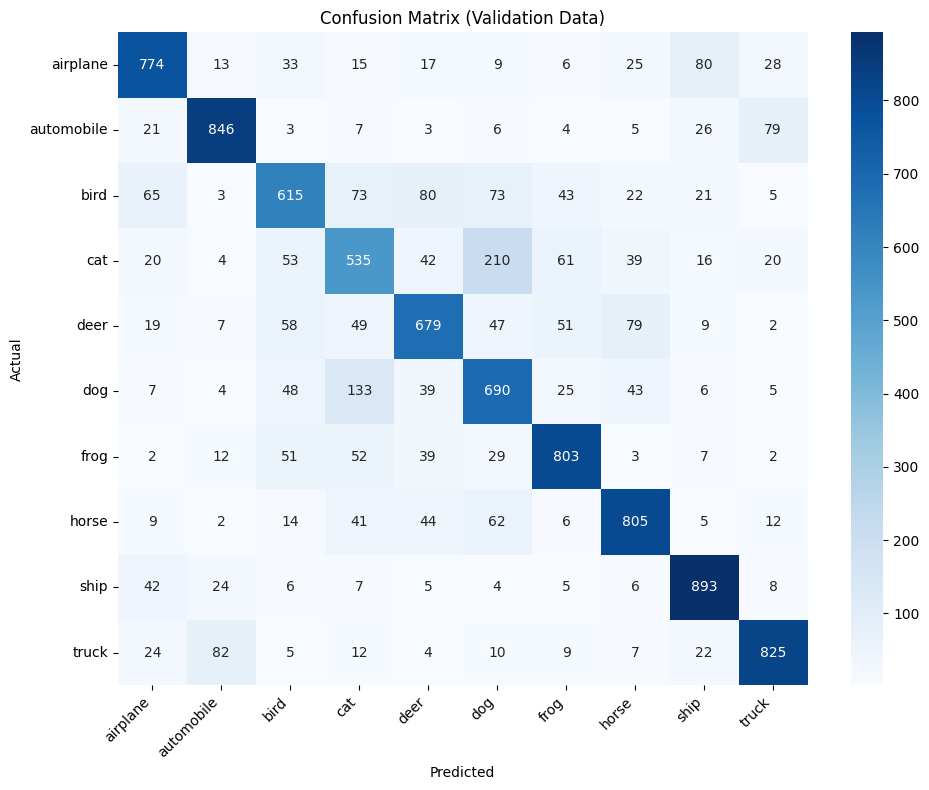


분류 리포트:
              precision    recall  f1-score   support

    airplane       0.79      0.77      0.78      1000
  automobile       0.85      0.85      0.85      1000
        bird       0.69      0.61      0.65      1000
         cat       0.58      0.54      0.56      1000
        deer       0.71      0.68      0.70      1000
         dog       0.61      0.69      0.64      1000
        frog       0.79      0.80      0.80      1000
       horse       0.78      0.81      0.79      1000
        ship       0.82      0.89      0.86      1000
       truck       0.84      0.82      0.83      1000

    accuracy                           0.75     10000
   macro avg       0.75      0.75      0.75     10000
weighted avg       0.75      0.75      0.75     10000


클래스별 정확도:
  airplane: 0.7740 (77.40%)
  automobile: 0.8460 (84.60%)
  bird: 0.6150 (61.50%)
  cat: 0.5350 (53.50%)
  deer: 0.6790 (67.90%)
  dog: 0.6900 (69.00%)
  frog: 0.8030 (80.30%)
  horse: 0.8050 (80.50%)
  ship: 0.8930 (89.3

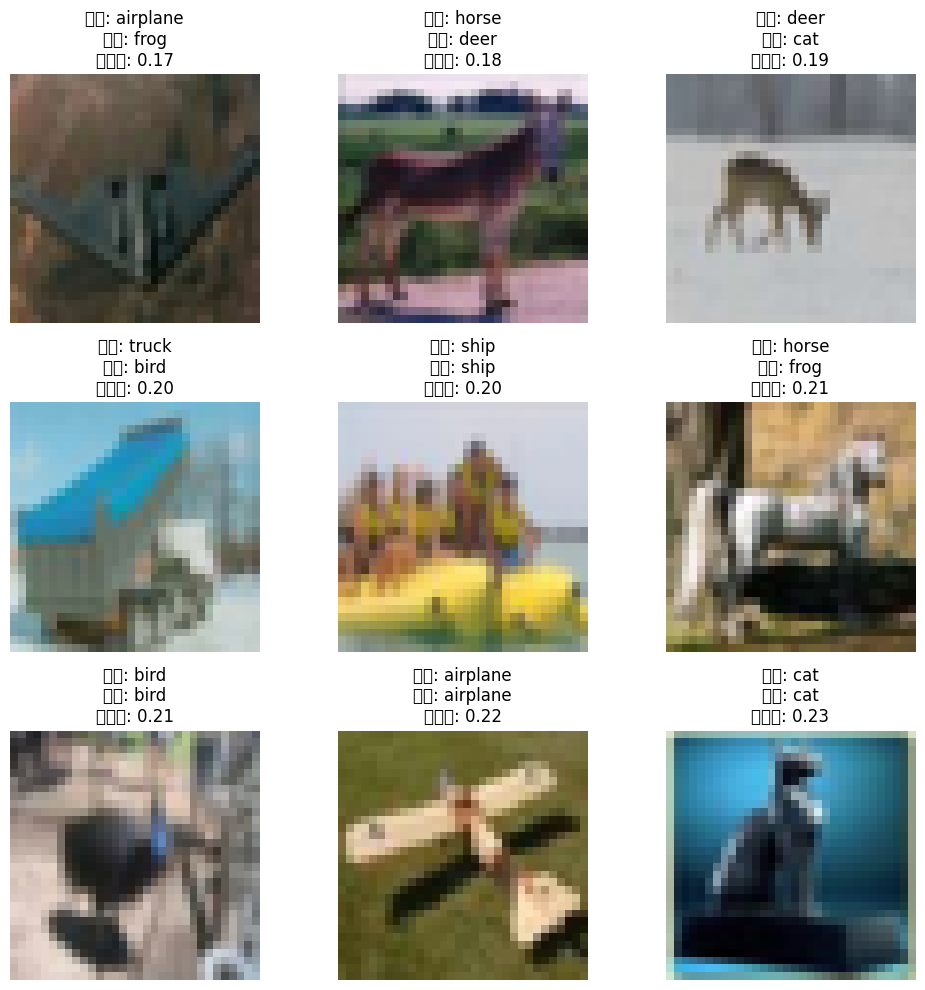

In [12]:
from sklearn.metrics import confusion_matrix, classification_report

import seaborn as sns

# 1. 예측 (10-class)

y_val_pred_proba = model.predict(X_val)

# ✅ TODO: 확률을 클래스 인덱스로 변환

y_val_pred = np.argmax(y_val_pred_proba, axis=1)

# 2. 혼동행렬 (10×10) 계산

# ✅ TODO: confusion_matrix 사용

cm = confusion_matrix(y_val, y_val_pred, labels=range(10))

plt.figure(figsize=(10, 8))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True,

            xticklabels=class_names,

            yticklabels=class_names)

plt.title('Confusion Matrix (Validation Data)')

plt.ylabel('Actual')

plt.xlabel('Predicted')

plt.xticks(rotation=45, ha='right')

plt.yticks(rotation=0)

plt.tight_layout()

plt.show()

# 3. 분류 리포트

print("\n분류 리포트:")

# ✅ TODO: classification_report 사용

print(classification_report(y_val, y_val_pred, target_names=class_names))

# 4. 클래스별 정확도

print(f"\n클래스별 정확도:")

for i, name in enumerate(class_names):

    class_mask = y_val == i

    if class_mask.sum() > 0:

        # ✅ TODO: 각 클래스 정확도 계산

        acc = np.sum(y_val_pred[class_mask] == i) / class_mask.sum()

        print(f"  {name}: {acc:.4f} ({acc*100:.2f}%)")

# 5. 가장 잘못 분류된 샘플 시각화

# 신뢰도가 낮은 샘플 찾기

confidence_scores = np.max(y_val_pred_proba, axis=1)

low_confidence_idx = np.argsort(confidence_scores)[:9]

fig, axes = plt.subplots(3, 3, figsize=(10, 10))

for i, idx in enumerate(low_confidence_idx):

    row, col = i // 3, i % 3

    axes[row, col].imshow(X_val[idx])

    actual = class_names[y_val[idx]]

    predicted = class_names[y_val_pred[idx]]

    conf = confidence_scores[idx]

    axes[row, col].set_title(f"실제: {actual}\n예측: {predicted}\n신뢰도: {conf:.2f}")

    axes[row, col].axis('off')

plt.tight_layout()

plt.show()



In [13]:
# 성능 비교 표

comparison = pd.DataFrame({

    'Dense Network (Day 3)': {

        '입력': '224×224×3 → 150,528 벡터',

        '파라미터': '약 77,246,660개',

        '예상 정확도': '70~78%',

        '훈련 시간': '2~5분',

        '메모리': '~2GB'

    },

    'CNN (Day 4)': {

        '입력': '32×32×3 (이미지 그대로)',

        '파라미터': f'{model.count_params():,}개',

        '검증 정확도': f'{val_acc*100:.2f}%',

        '훈련 시간': '3~5분',

        '메모리': '~500MB'

    }

})

print("\n=== Dense Network vs CNN 비교 ===")

print(comparison.to_string())

# 핵심 차이점

print("\n핵심 차이점:")

print("1. 파라미터 수:")

print(f"   - Dense: 77,246,660개 (약 77M)")

print(f"   - CNN: {model.count_params():,}개 (약 {model.count_params()/1e6:.1f}M)")

print(f"   - CNN이 약 {77246660/model.count_params():.0f}배 더 효율적!")

print("\n2. 공간 정보 보존:")

print("   - Dense: 이미지를 1D 벡터로 변환 → 공간 정보 손실")

print("   - CNN: 2D 구조 유지 → 인접 픽셀 관계 학습")

print("\n3. 특징 학습:")

print("   - Dense: 전체 픽셀을 함께 처리")

print("   - CNN: 지역 패턴부터 시작 (엣지→텍스처→객체)")



=== Dense Network vs CNN 비교 ===
         Dense Network (Day 3)        CNN (Day 4)
입력      224×224×3 → 150,528 벡터  32×32×3 (이미지 그대로)
파라미터             약 77,246,660개           620,362개
예상 정확도                  70~78%                NaN
훈련 시간                     2~5분               3~5분
메모리                       ~2GB             ~500MB
검증 정확도                     NaN             74.65%

핵심 차이점:
1. 파라미터 수:
   - Dense: 77,246,660개 (약 77M)
   - CNN: 620,362개 (약 0.6M)
   - CNN이 약 125배 더 효율적!

2. 공간 정보 보존:
   - Dense: 이미지를 1D 벡터로 변환 → 공간 정보 손실
   - CNN: 2D 구조 유지 → 인접 픽셀 관계 학습

3. 특징 학습:
   - Dense: 전체 픽셀을 함께 처리
   - CNN: 지역 패턴부터 시작 (엣지→텍스처→객체)
